In [8]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

## Practice Lab 14 - Support Vector Machines

Load the Iris data set and fit a SVM classification model for petals widths.
The code below selects 2/3 of the iris dataset, only those instances that are either Setosa or Versicolor.

In [10]:
from sklearn import datasets
iris = datasets.load_iris()

X = iris["data"][:, (2, 3)]  # petal length, petal width
y = iris["target"]

setosa_or_versicolor = (y == 0) | (y == 1)
X = X[setosa_or_versicolor]
y = y[setosa_or_versicolor]

print(X.shape)
print(y.shape)
print('petal length range',X[:,0].min(),X[:,0].max())
print('petal width range',X[:,1].min(),X[:,1].max())
print(y)

(100, 2)
(100,)
petal length range 1.0 5.1
petal width range 0.1 1.8
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


### Exercise 1: Plotting boundaries 
Use sklearn to write a SVC (support vector classifier) and plot the results as a function of petal width and length.\
The decision function is ${\bf w^T x} + b = 0$ or in this case, $w[0] \times x0 + w[1] \times x1 + b = 0$. 

a) Plot the data X, with X[:,0] on the horizontal axis and X[:,1] on the vertical axis\
b) Plot the boundary calculating x[1] as a function of x[0] for a regularly sampled axis x[0].\
c) Plot the margins ($margin=\frac{1}{w[1]}$)

In [16]:
# SVM Classifier model
from sklearn.svm import SVC
svm_clf = SVC(kernel="linear", C=float("inf"))
svm_clf.fit(X, y)
w = svm_clf.coef_[0]
b = svm_clf.intercept_[0]
print(w,b)
x0 = np.linspace(X[:,0].min(), X[:,0].max(), 200)
print(x0.shape)                
x1 = -w[0]/w[1] * x0 - b/w[1]
print(x1.shape)
margin=1/w[1]

[1.29411744 0.82352928] -3.7882347112962464
(200,)
(200,)


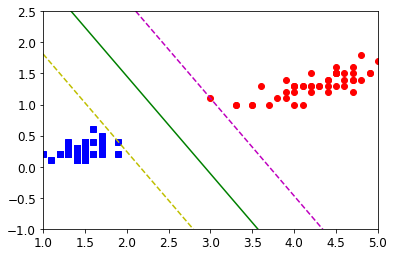

In [20]:
plt.plot(X[:,0][y==0],X[:,1][y==0],'bs')
plt.plot(X[:,0][y==1],X[:,1][y==1],'ro')
plt.plot(x0,x1,'g-')
plt.plot(x0,x1+margin,'m--')
plt.plot(x0,x1-margin,'y--')
plt.axis([1,5,-1,2.5]);

### Exercise 2:
Use the code below to generate the moons data set and then use a non-linear separation

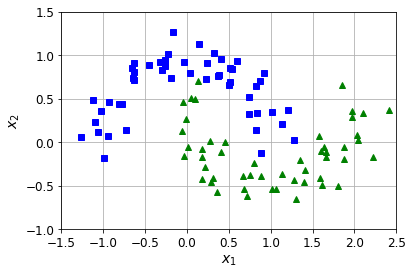

In [5]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
    plt.axis(axes)
    plt.grid(True, which='both')
    plt.xlabel(r"$x_1$")
    plt.ylabel(r"$x_2$")

plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])
plt.show()

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
polynomial_svm_clf = Pipeline([("poly_features", PolynomialFeatures(degree=3)),
                              ("scaler",StandardScaler()),
                              ("svm_clf",LinearSVC(C=10, loss="hinge", random_state=42))])
polynomial_svm_clf.fit(X,y)

/home/dtrad/anaconda3/lib/python3.7/site-packages/sklearn/svm/base.py:929: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)


Pipeline(memory=None,
         steps=[('poly_features',
                 PolynomialFeatures(degree=3, include_bias=True,
                                    interaction_only=False, order='C')),
                ('scaler',
                 StandardScaler(copy=True, with_mean=True, with_std=True)),
                ('svm_clf',
                 LinearSVC(C=10, class_weight=None, dual=True,
                           fit_intercept=True, intercept_scaling=1,
                           loss='hinge', max_iter=1000, multi_class='ovr',
                           penalty='l2', random_state=42, tol=0.0001,
                           verbose=0))],
         verbose=False)

(100, 100)
(10000,)
(10000, 2)
(10000,)
(100, 100)
(100, 100)


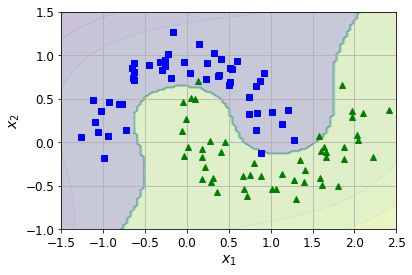

In [7]:
def plot_predictions(clf,axes):
    x0s=np.linspace(axes[0],axes[1],100)
    x1s=np.linspace(axes[2],axes[3],100)
    x0,x1 = np.meshgrid(x0s,x1s)
    X = np.c_[x0.ravel(),x1.ravel()]
    print(x0.shape)
    print(x0.ravel().shape)
    print(X.shape)
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    print(clf.predict(X).shape)
    print(y_pred.shape)
    print(y_decision.shape)
    plt.contourf(x0,x1,y_pred, alpha=0.2)
    plt.contourf(x0,x1,y_decision, alpha=0.1)
#plt.show()
axes=[-1.5, 2.5, -1, 1.5]
plot_predictions(polynomial_svm_clf, axes)
#plt.show()
plot_dataset(X, y, axes )